In [ ]:
!pip install -q kaggle
!pip install iterative-stratification lightning datasets evaluate

In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content/'

In [ ]:
!chmod 600 /content/kaggle.json

In [ ]:
!kaggle competitions download -c 2110446-dsde-2025-2

2110446-dsde-2025-2.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o 2110446-dsde-2025-2.zip

Archive:  2110446-dsde-2025-2.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


# Data Preparation

In [ ]:
import pandas as pd
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.font_manager as fm

In [ ]:
if not os.path.exists('THSarabunNew.ttf'):
    !wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf -O THSarabunNew.ttf

# 2. เพิ่มฟอนต์เข้าไปใน Matplotlib Font Manager
fe = fm.FontEntry(
    fname='THSarabunNew.ttf',
    name='ThaiSarabun') # ตั้งชื่อเรียกง่ายๆ ว่า ThaiSarabun
fm.fontManager.ttflist.insert(0, fe)

# 3. ตั้งค่า Default ให้ทุกอย่างใช้ฟอนต์นี้
plt.rcParams['font.family'] = fe.name
plt.rcParams['axes.unicode_minus'] = False  # แก้ปัญหาเครื่องหมายลบแสดงผลไม่ได้

print("Setup สำเร็จ! ต่อจากนี้พล็อตภาษาไทยได้เลยโดยไม่ต้องตั้งค่าเพิ่ม")

Setup สำเร็จ! ต่อจากนี้พล็อตภาษาไทยได้เลยโดยไม่ต้องตั้งค่าเพิ่ม


In [ ]:
df = pd.read_csv('train.csv')
df.head()

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,0,ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว,0,0,0,0,0,0,0,0,0,0,0,0
1,1,แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...,0,0,0,0,0,0,0,0,0,0,0,0
2,2,คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง ส่ง...,0,0,0,0,0,0,0,0,0,0,0,0
3,3,ไม่แน่ใจ กทม อนุญาตให้ร้านชอคโกแลตวิลจุพลุถึงก...,0,0,0,0,0,0,0,0,0,0,0,0
4,4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.set_index('id', inplace=True)

In [ ]:
df.isnull().sum()

,0
comment,2135
สำนักงานตำรวจแห่งชาติ,0
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,0
สภาเด็กและเยาวชนกรุงเทพมหานคร,0
กรมควบคุมมลพิษ,0
กรมสรรพสามิต,0
การไฟฟ้านครหลวง,0
กรมทางหลวง,0
สำนักงานประกันสุขภาพแห่งชาติ,0
การประปานครหลวง,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df_clean = df.drop_duplicates(subset=['comment'], keep='first')

In [ ]:
df_clean.isnull().sum()

,0
comment,0
สำนักงานตำรวจแห่งชาติ,0
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,0
สภาเด็กและเยาวชนกรุงเทพมหานคร,0
กรมควบคุมมลพิษ,0
กรมสรรพสามิต,0
การไฟฟ้านครหลวง,0
กรมทางหลวง,0
สำนักงานประกันสุขภาพแห่งชาติ,0
การประปานครหลวง,0


In [ ]:
df_clean.shape, df.shape

((274585, 13), (304284, 13))

In [ ]:
df_clean['comment'] = df['comment'].str.strip()
idx = df_clean[df['comment'].str.len()<=2].index
print(df_clean.shape)
df_drop_length = df_clean.drop(idx, axis=0)
print(df_drop_length.shape)

/tmp/ipython-input-510921032.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['comment'] = df['comment'].str.strip()


(274585, 13)
(274567, 13)


/tmp/ipython-input-510921032.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  idx = df_clean[df['comment'].str.len()<=2].index


In [ ]:
import re
def clean_thai_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'[\n\r\t]+', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    text = re.sub(r'[\._-]{2,}', ' ', text)

    text = text.strip()

    return text

In [ ]:
df_drop_length['comment_cleaned'] = df_drop_length['comment'].apply(clean_thai_text)

In [ ]:
max_length_cm = df_drop_length['comment_cleaned'].str.len().max()
print(max_length_cm)
df_drop_length[df_drop_length['comment_cleaned'].str.len() == max_length_cm]['comment_cleaned']

9877


,comment_cleaned
id,
287235,เรียนท่านผู้ว่าราชการกรุงเทพมหานคร อธิบดีกรมเจ...


In [ ]:
x = df_drop_length['comment_cleaned']
y = df_drop_length.loc[:,"สำนักงานตำรวจแห่งชาติ":"สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200"]

In [ ]:
y.count()

,0
สำนักงานตำรวจแห่งชาติ,274567
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,274567
สภาเด็กและเยาวชนกรุงเทพมหานคร,274567
กรมควบคุมมลพิษ,274567
กรมสรรพสามิต,274567
การไฟฟ้านครหลวง,274567
กรมทางหลวง,274567
สำนักงานประกันสุขภาพแห่งชาติ,274567
การประปานครหลวง,274567
คณะกรรมการการพัฒนาเศรษฐกิจ,274567


In [ ]:
label_counts = y.sum()
label_counts

,0
สำนักงานตำรวจแห่งชาติ,31946
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,2492
สภาเด็กและเยาวชนกรุงเทพมหานคร,29
กรมควบคุมมลพิษ,1825
กรมสรรพสามิต,44
การไฟฟ้านครหลวง,18475
กรมทางหลวง,6887
สำนักงานประกันสุขภาพแห่งชาติ,69
การประปานครหลวง,2800
คณะกรรมการการพัฒนาเศรษฐกิจ,30


In [ ]:
import numpy as np
mx = x.str.len().max()
len_from_3_tomax = [0]*(mx+1)
for i in x:
  l = len(i)
  len_from_3_tomax[l]+=1

In [ ]:
ll = [50*(i+1) for i in range(20)]

In [ ]:
df_drop_length.loc[df_drop_length['comment_cleaned'].str.len() >= 400,"สำนักงานตำรวจแห่งชาติ":"สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200"].sum()

,0
สำนักงานตำรวจแห่งชาติ,2915
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,229
สภาเด็กและเยาวชนกรุงเทพมหานคร,2
กรมควบคุมมลพิษ,207
กรมสรรพสามิต,11
การไฟฟ้านครหลวง,1178
กรมทางหลวง,357
สำนักงานประกันสุขภาพแห่งชาติ,21
การประปานครหลวง,205
คณะกรรมการการพัฒนาเศรษฐกิจ,4


In [ ]:
label_counts

,0
สำนักงานตำรวจแห่งชาติ,31946
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,2492
สภาเด็กและเยาวชนกรุงเทพมหานคร,29
กรมควบคุมมลพิษ,1825
กรมสรรพสามิต,44
การไฟฟ้านครหลวง,18475
กรมทางหลวง,6887
สำนักงานประกันสุขภาพแห่งชาติ,69
การประปานครหลวง,2800
คณะกรรมการการพัฒนาเศรษฐกิจ,30


In [ ]:
col = df_drop_length.columns[1:-1]
col

Index(['สำนักงานตำรวจแห่งชาติ', 'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย',
       'สภาเด็กและเยาวชนกรุงเทพมหานคร', 'กรมควบคุมมลพิษ', 'กรมสรรพสามิต',
       'การไฟฟ้านครหลวง', 'กรมทางหลวง', 'สำนักงานประกันสุขภาพแห่งชาติ',
       'การประปานครหลวง', 'คณะกรรมการการพัฒนาเศรษฐกิจ',
       'กระทรวงการท่องเที่ยวและกีฬา', 'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200'],
      dtype='object')

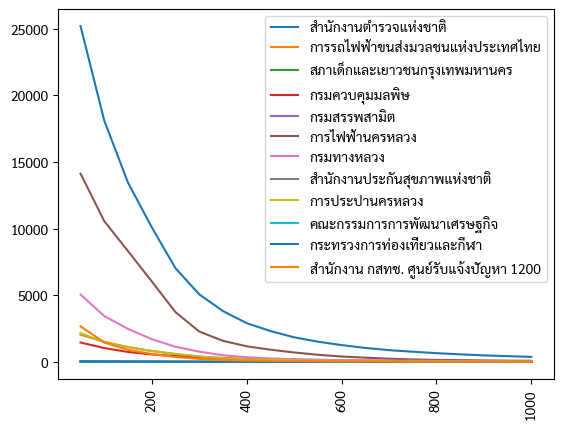

In [ ]:
list_rate = []
for l in ll:
  val = df_drop_length.loc[df_drop_length['comment_cleaned'].str.len() >= l,"สำนักงานตำรวจแห่งชาติ":"สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200"].sum().values
  list_rate.append(val)
list_rate = np.array(list_rate)
for i in range(len(col)):
  plt.plot(ll, list_rate[:,i], label=f'{col[i]}')

plt.xticks(rotation=90, fontsize=10)
plt.legend()
plt.show()


(array([9.484e+03, 8.000e+01, 5.200e+01, 4.200e+01, 8.000e+01, 3.700e+01,
        1.800e+01, 1.600e+01, 1.100e+01, 1.200e+01, 6.000e+00, 1.300e+01,
        1.100e+01, 5.000e+00, 1.100e+01]),
 array([   0.        ,  125.26666667,  250.53333333,  375.8       ,
         501.06666667,  626.33333333,  751.6       ,  876.86666667,
        1002.13333333, 1127.4       , 1252.66666667, 1377.93333333,
        1503.2       , 1628.46666667, 1753.73333333, 1879.        ]),
 <BarContainer object of 15 artists>)

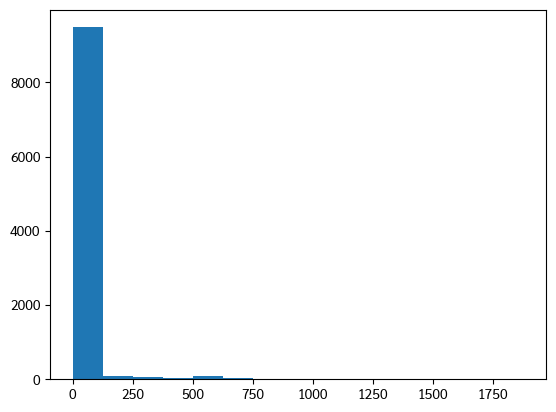

In [ ]:
plt.hist(len_from_3_tomax, bins=15)

# Model And Tokenizer


In [ ]:
import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer
from datasets import Dataset
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import evaluate

In [ ]:
model_path = "clicknext/phayathaibert"
tokenizer = AutoTokenizer.from_pretrained(model_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
# now not use

In [ ]:
for train_index, test_index in msss.split(x, y):
    train_x, test_x = x.iloc[train_index], x.iloc[test_index]
    train_y, test_y = y.iloc[train_index], y.iloc[test_index]

for validation_index, test_index in msss.split(test_x, test_y):
    validation_x, real_test_x = test_x.iloc[validation_index], test_x.iloc[test_index]
    validation_y, real_test_y = test_y.iloc[validation_index], test_y.iloc[test_index]


In [ ]:
print(train_y.shape)
print(validation_y.shape)
print(real_test_y.shape)

(164740, 12)
(65896, 12)
(43931, 12)


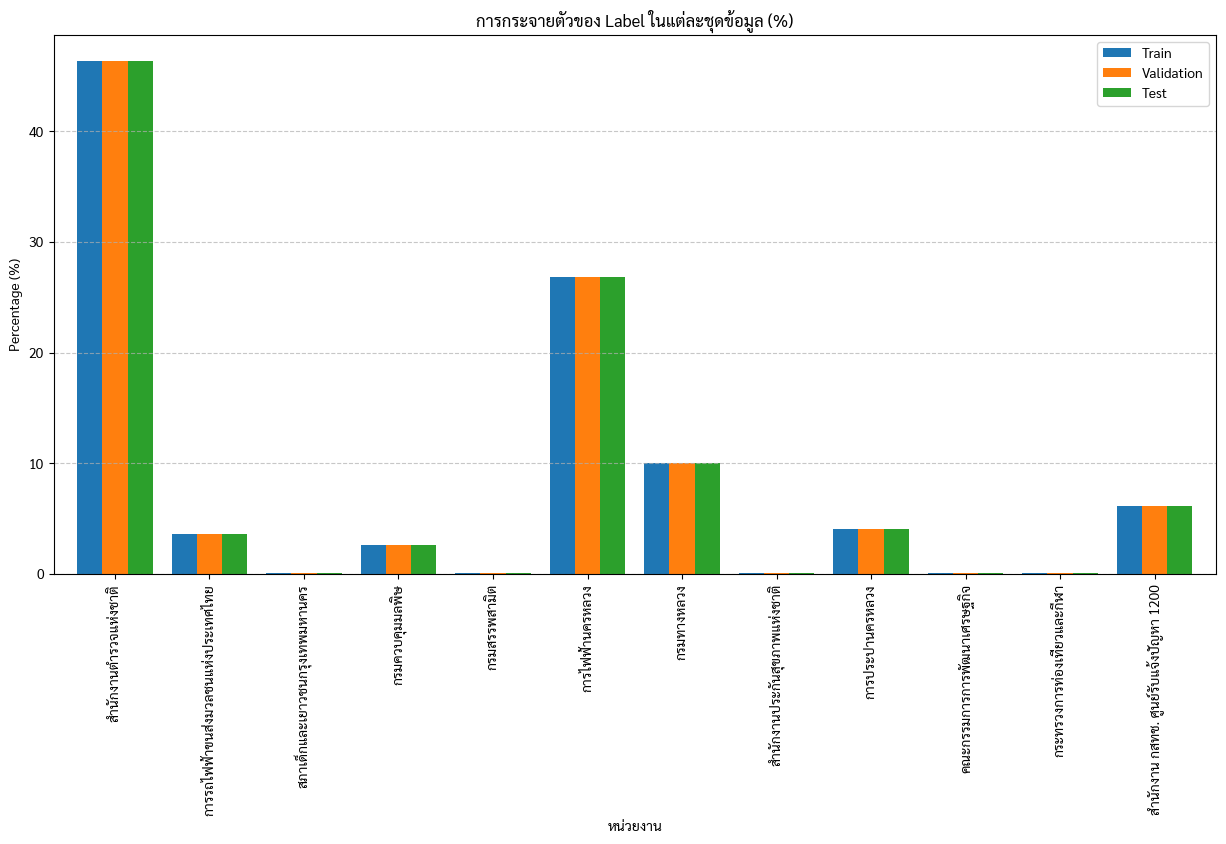

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

train_counts = train_y.sum()
val_counts = validation_y.sum()
test_counts = real_test_y.sum()

dist_df = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
})

dist_pct = dist_df.div(dist_df.sum(axis=0), axis=1) * 100

dist_pct.plot(kind='bar', figsize=(15, 7), width=0.8)

plt.title('การกระจายตัวของ Label ในแต่ละชุดข้อมูล (%)')
plt.ylabel('Percentage (%)')
plt.xlabel('หน่วยงาน')
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
train_x

,comment_cleaned
id,
1,แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...
4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...
5,หลายสถานที่ จัดงานฉลองปีใหม่กันเสียงดังลั่นเมื...
6,ฝาท่อชำรุด คู้บอน27
7,ป้ายประชาสัมพันธ์บดบังป้ายซอยทางเข้า ทำให้แท็ก...
...,...
306403,เสาไปส่องสว่างริมถนนวิภาวดีรังสิต ปากซอยวิภาวด...
306407,ที่กั้นสะพานชำรุดและแสงไฟไม่เพียงพอ อันตรายเมื...
306413,มีหลุมถนน


In [ ]:
pd.concat([train_x, train_y], axis=1)

,comment_cleaned,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
id,,,,,,,,,,,,,
1,แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...,0,0,0,0,0,0,0,0,0,0,0,0
4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...,0,0,0,0,0,0,0,0,0,0,0,0
5,หลายสถานที่ จัดงานฉลองปีใหม่กันเสียงดังลั่นเมื...,0,0,0,0,0,0,0,0,0,0,0,0
6,ฝาท่อชำรุด คู้บอน27,0,0,0,0,0,0,0,0,0,0,0,0
7,ป้ายประชาสัมพันธ์บดบังป้ายซอยทางเข้า ทำให้แท็ก...,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
306403,เสาไปส่องสว่างริมถนนวิภาวดีรังสิต ปากซอยวิภาวด...,0,1,0,0,0,0,1,0,0,0,0,0
306407,ที่กั้นสะพานชำรุดและแสงไฟไม่เพียงพอ อันตรายเมื...,0,0,0,0,0,0,0,0,0,0,0,0
306413,มีหลุมถนน,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_set = Dataset.from_pandas(pd.concat([train_x, train_y], axis=1))
validation_set = Dataset.from_pandas(pd.concat([validation_x, validation_y], axis=1))
test_set = Dataset.from_pandas(pd.concat([real_test_x, real_test_y], axis=1))

In [ ]:
train_set

Dataset({
    features: ['comment_cleaned', 'สำนักงานตำรวจแห่งชาติ', 'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย', 'สภาเด็กและเยาวชนกรุงเทพมหานคร', 'กรมควบคุมมลพิษ', 'กรมสรรพสามิต', 'การไฟฟ้านครหลวง', 'กรมทางหลวง', 'สำนักงานประกันสุขภาพแห่งชาติ', 'การประปานครหลวง', 'คณะกรรมการการพัฒนาเศรษฐกิจ', 'กระทรวงการท่องเที่ยวและกีฬา', 'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200', 'id'],
    num_rows: 164740
})

In [ ]:
class2id = {classes:id for id, classes in enumerate(train_y.columns)}
id2class = {id:classes for classes, id in class2id.items()}

In [ ]:
class2id,id2class

({'สำนักงานตำรวจแห่งชาติ': 0,
  'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย': 1,
  'สภาเด็กและเยาวชนกรุงเทพมหานคร': 2,
  'กรมควบคุมมลพิษ': 3,
  'กรมสรรพสามิต': 4,
  'การไฟฟ้านครหลวง': 5,
  'กรมทางหลวง': 6,
  'สำนักงานประกันสุขภาพแห่งชาติ': 7,
  'การประปานครหลวง': 8,
  'คณะกรรมการการพัฒนาเศรษฐกิจ': 9,
  'กระทรวงการท่องเที่ยวและกีฬา': 10,
  'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200': 11},
 {0: 'สำนักงานตำรวจแห่งชาติ',
  1: 'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย',
  2: 'สภาเด็กและเยาวชนกรุงเทพมหานคร',
  3: 'กรมควบคุมมลพิษ',
  4: 'กรมสรรพสามิต',
  5: 'การไฟฟ้านครหลวง',
  6: 'กรมทางหลวง',
  7: 'สำนักงานประกันสุขภาพแห่งชาติ',
  8: 'การประปานครหลวง',
  9: 'คณะกรรมการการพัฒนาเศรษฐกิจ',
  10: 'กระทรวงการท่องเที่ยวและกีฬา',
  11: 'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200'})

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=12,
    id2label=id2class,
    label2id=class2id,
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: clicknext/phayathaibert
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer,
                                        padding=True,
                                        max_length=510)

In [ ]:
cols = col

In [ ]:
target_columns = [
    'สำนักงานตำรวจแห่งชาติ', 'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย',
    'สภาเด็กและเยาวชนกรุงเทพมหานคร', 'กรมควบคุมมลพิษ', 'กรมสรรพสามิต',
    'การไฟฟ้านครหลวง', 'กรมทางหลวง', 'สำนักงานประกันสุขภาพแห่งชาติ',
    'การประปานครหลวง', 'คณะกรรมการการพัฒนาเศรษฐกิจ',
    'กระทรวงการท่องเที่ยวและกีฬา', 'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200'
]

def preprocess_function(examples):
    tokenized_inputs = tokenizer(
        examples["comment_cleaned"],
        truncation=True,
        # max_length=512,
        # padding="max_length"
    )

    labels_batch = []
    for i in range(len(examples["comment_cleaned"])):
        label_row = [float(examples[col][i]) for col in target_columns]
        labels_batch.append(label_row)

    tokenized_inputs["labels"] = labels_batch
    return tokenized_inputs

In [ ]:
tokenized_train = train_set.map(
    preprocess_function,
    batched=True,
    remove_columns=train_set.column_names
)
tokenized_validation = validation_set.map(
    preprocess_function,
    batched=True,
    remove_columns=validation_set.column_names
)
# tokenized_test = test_set.map(preprocess_function, batched=True)

Map:   0%|          | 0/164740 [00:00<?, ? examples/s]

Map:   0%|          | 0/65896 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
train_labels = np.array(tokenized_train['labels'])
print(f"Unique labels in train: {np.unique(train_labels)}")
print(f"Max label: {train_labels.max()}")

print(tokenized_train[0].keys())

Unique labels in train: [0. 1.]
Max label: 1.0
dict_keys(['input_ids', 'attention_mask', 'labels'])


In [ ]:
print(tokenized_train[0]['labels'])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [ ]:
tokenized_train.set_format("torch")
tokenized_validation.set_format("torch")

In [ ]:
tokenized_train

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 164740
})

In [ ]:
train_args= TrainingArguments(
    output_dir="output",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8, # Reduce ram using
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    learning_rate=2e-5,
    load_best_model_at_end=True,
    report_to='none',
    metric_for_best_model="f1_macro",
    # fp16=True,
    save_total_limit=2,
)

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
THRESHOLD = 0.5
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))

    predictions = (probs > 0.5).astype(int)

    f1_micro = f1_score(labels, predictions, average="micro", zero_division=0)
    f1_macro = f1_score(labels, predictions, average="macro", zero_division=0)
    accuracy = accuracy_score(labels, predictions)
    return {
        "f1": f1_micro,
        "f1_macro": f1_macro,
        "accuracy": accuracy
    }

In [ ]:
from transformers import default_data_collator
trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 6, 'bos_token_id': 5}.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Epoch,Training Loss,Validation Loss


In [ ]:
trainer.save_model("model")